# Лабораторная работа 2. Спайковые нейронные сети (SNN)

## Вариант 2.4 — сеть с тормозными интернейронами

**Цель работы:** практическое освоение принципов нейроморфных вычислений через моделирование и анализ простой спайковой нейронной сети.

В данной работе реализуется сеть LIF-нейронов, в скрытом слое которой **20% нейронов являются тормозными**. Это означает, что при их срабатывании они создают **отрицательные постсинаптические токи**, уменьшая вероятность возбуждения других нейронов. Такой механизм нужен для исследования **баланса возбуждения и торможения** и его влияния на устойчивость сети, разреженность активности и качество распознавания.

## Что будет реализовано

1. **LIF-нейрон** и исследование его отклика на разные входные токи.  
2. **SNN с рекуррентными связями в скрытом слое**, где 20% нейронов тормозные.  
3. **Обучение входных весов по правилу STDP**.  
4. **Классификация простых паттернов** на основе спайковой активности скрытого слоя.  
5. **Сравнительный анализ**:
   - с торможением и без торможения;
   - по точности на чистых и зашумленных данных;
   - по числу спайков как грубой оценке энергозатрат;
   - по роли временного кода (spike count vs first-spike time).

## Теоретические сведения

### 1. Модель LIF-нейрона

Модель **Leaky Integrate-and-Fire** описывается уравнением:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t)-V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал;
- $V_{rest}$ — потенциал покоя;
- $\tau_m$ — постоянная времени мембраны;
- $R_m I(t)$ — вклад входного тока.

Если потенциал достигает порога $V_{th}$, нейрон генерирует **спайк**, после чего потенциал сбрасывается до $V_{reset}$ и нейрон входит в рефрактерное состояние.

### 2. Правило STDP

В работе используется трассовая форма STDP. Для каждого пресинаптического и постсинаптического нейрона поддерживаются следы активности:

$$
x_{pre}(t+1) = x_{pre}(t)e^{-dt/\tau_{pre}} + s_{pre}(t),
$$

$$
x_{post}(t+1) = x_{post}(t)e^{-dt/\tau_{post}} + s_{post}(t)
$$

Тогда изменение веса можно записать как:
- при **постспайке**: усиливаются недавно активные входы,
- при **преспайке**: немного ослабляются связи с недавно активными постнейронами.

### 3. Возбуждающе-тормозной баланс

В скрытом слое часть нейронов делает сеть более устойчивой:
- возбуждающие нейроны повышают активность сети;
- тормозные нейроны подавляют избыточную синхронизацию;
- в результате формируется более разреженное и устойчивое кодирование.

В данной работе доля тормозных нейронов фиксируется на уровне **20%**, как требуется в варианте.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [16]:
@dataclass
class LIFNeuron:
    tau_m: float = 20.0
    v_rest: float = -65.0
    v_reset: float = -70.0
    v_thresh: float = -52.0
    r_m: float = 1.0
    tau_ref: float = 4.0

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.v = self.v_rest
        self.ref_until = -np.inf
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        if t < self.ref_until:
            self.v = self.v_reset
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dt * dv

        if self.v >= self.v_thresh:
            self.spike_times.append(t)
            self.v = self.v_reset
            self.ref_until = t + self.tau_ref
            return True
        return False

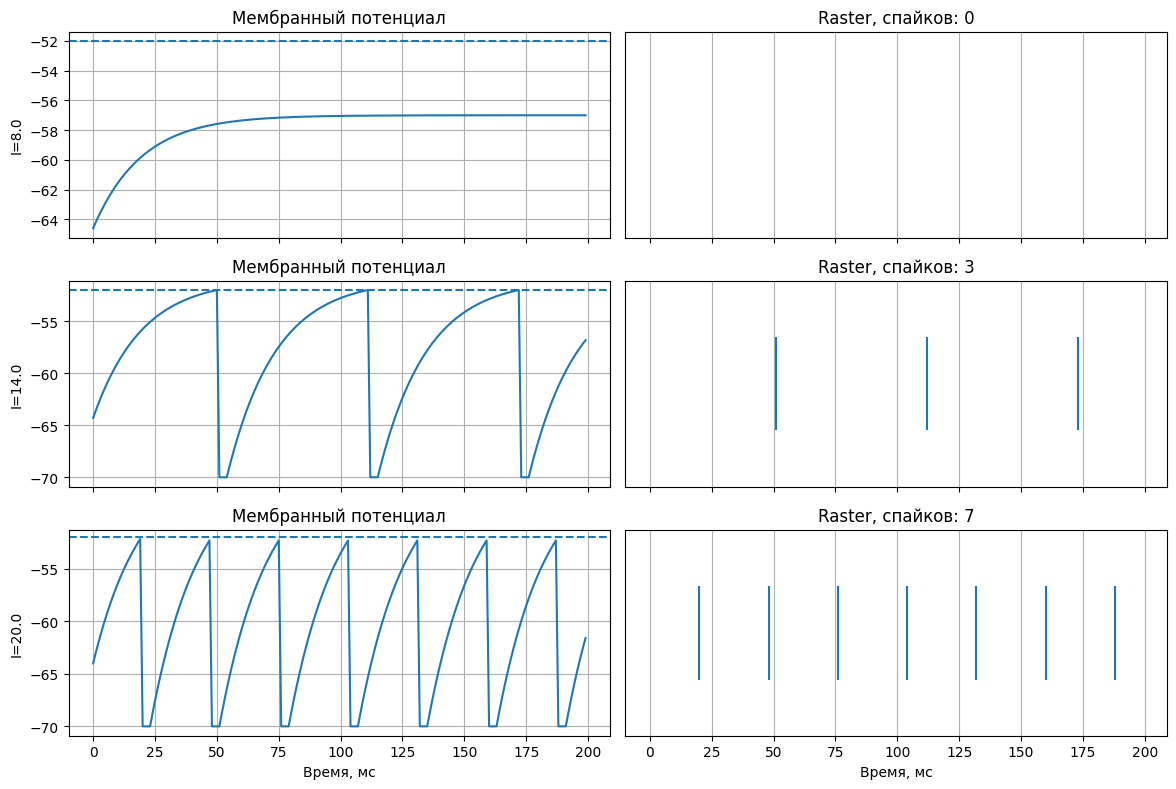

In [ ]:
dt = 1.0
T = 200
times = np.arange(0, T, dt)
currents = [8.0, 14.0, 20.0]

fig, axes = plt.subplots(len(currents), 2, figsize=(12, 8), sharex=True)

for row, I_const in enumerate(currents):
    neuron = LIFNeuron()
    v_trace = []
    spikes = []
    for t in times:
        spike = neuron.step(I_const, dt, t)
        v_trace.append(neuron.v)
        if spike:
            spikes.append(t)

    axes[row, 0].plot(times, v_trace)
    axes[row, 0].axhline(neuron.v_thresh, linestyle="--")
    axes[row, 0].set_ylabel(f"I={I_const}")
    axes[row, 0].set_title("Мембранный потенциал")

    axes[row, 1].eventplot(spikes, lineoffsets=1, linelengths=0.8)
    axes[row, 1].set_yticks([])
    axes[row, 1].set_title(f"Raster, спайков: {len(spikes)}")

axes[-1, 0].set_xlabel("Время, мс")
axes[-1, 1].set_xlabel("Время, мс")
plt.tight_layout()
plt.show()

### Вывод по одиночному нейрону

При увеличении постоянного входного тока мембранный потенциал быстрее достигает порога, а частота спайков растёт.  
Это подтверждает корректную реализацию модели LIF и показывает базовый механизм преобразования входного тока во временную последовательность спайков.

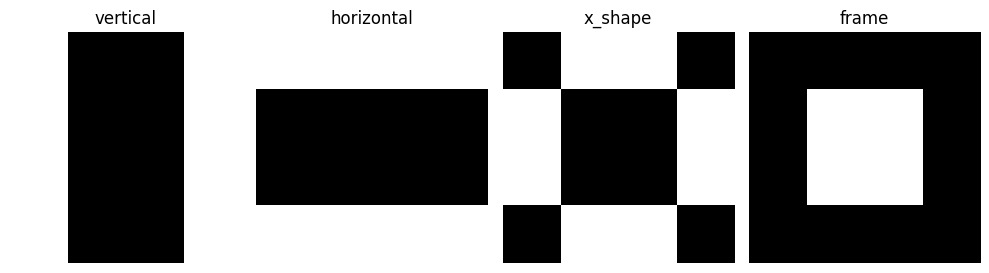

In [ ]:
def make_patterns() -> Tuple[np.ndarray, np.ndarray, List[str]]:
    p0 = np.array([
        [0,1,1,0],
        [0,1,1,0],
        [0,1,1,0],
        [0,1,1,0],
    ], dtype=float)

    p1 = np.array([
        [0,0,0,0],
        [1,1,1,1],
        [1,1,1,1],
        [0,0,0,0],
    ], dtype=float)

    p2 = np.array([
        [1,0,0,1],
        [0,1,1,0],
        [0,1,1,0],
        [1,0,0,1],
    ], dtype=float)

    p3 = np.array([
        [1,1,1,1],
        [1,0,0,1],
        [1,0,0,1],
        [1,1,1,1],
    ], dtype=float)

    X = np.stack([p0, p1, p2, p3]).reshape(4, -1)
    y = np.arange(4)
    names = ["vertical", "horizontal", "x_shape", "frame"]
    return X, y, names

X_base, y_base, class_names = make_patterns()

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_base[i].reshape(4, 4), cmap="gray_r")
    ax.set_title(class_names[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

### Создали на будущее простые паттерны для обучения сети

In [19]:
def make_dataset(samples_per_class=80, noise_std=0.15, seed=42):
    rng_local = np.random.default_rng(seed)
    X, y, _ = make_patterns()
    X_list, y_list = [], []

    for cls in range(len(X)):
        for _ in range(samples_per_class):
            sample = X[cls] + rng_local.normal(0, noise_std, size=X.shape[1])
            sample = np.clip(sample, 0.0, 1.0)
            X_list.append(sample)
            y_list.append(cls)

    X_arr = np.array(X_list)
    y_arr = np.array(y_list)

    idx = rng_local.permutation(len(X_arr))
    return X_arr[idx], y_arr[idx]

X_train, y_train = make_dataset(samples_per_class=80, noise_std=0.12, seed=1)
X_test_clean, y_test_clean = make_dataset(samples_per_class=30, noise_std=0.08, seed=2)
X_test_noisy, y_test_noisy = make_dataset(samples_per_class=30, noise_std=0.28, seed=3)

print("Train:", X_train.shape, "Test clean:", X_test_clean.shape, "Test noisy:", X_test_noisy.shape)

Train: (320, 16) Test clean: (120, 16) Test noisy: (120, 16)


In [ ]:
class EI_SNN:
    def __init__(
        self,
        n_input=16,
        n_hidden=10,
        inhibitory_fraction=0.2,
        dt=1.0,
        sim_time=100,
        rate_low=20.0,
        rate_high=220.0,
        tau_m=20.0,
        v_rest=-65.0,
        v_reset=-70.0,
        v_thresh=-60.0,
        tau_ref=3.0,
        tau_syn=8.0,
        stdp_lr_plus=0.0015,
        stdp_lr_minus=0.0012,
        tau_pre=20.0,
        tau_post=20.0,
        w_min=0.0,
        w_max=12.0,
        w_rec_exc=2.0,
        w_rec_inh=-4.5,
        seed=42,
    ):
        self.rng = np.random.default_rng(seed)
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_inh = int(round(n_hidden * inhibitory_fraction))
        self.n_exc = n_hidden - self.n_inh
        self.inhibitory_fraction = inhibitory_fraction

        self.dt = dt
        self.sim_time = sim_time
        self.steps = int(sim_time / dt)
        self.rate_low = rate_low
        self.rate_high = rate_high

        self.tau_m = tau_m
        self.v_rest = v_rest
        self.v_reset = v_reset
        self.v_thresh = v_thresh
        self.tau_ref = tau_ref
        self.tau_syn = tau_syn

        self.stdp_lr_plus = stdp_lr_plus
        self.stdp_lr_minus = stdp_lr_minus
        self.tau_pre = tau_pre
        self.tau_post = tau_post
        self.w_min = w_min
        self.w_max = w_max

        self.hidden_types = np.ones(n_hidden)
        if self.n_inh > 0:
            self.hidden_types[-self.n_inh:] = -1.0 

        self.W_in = self.rng.uniform(3.5, 8.0, size=(n_input, n_hidden))

        self.W_rec = np.zeros((n_hidden, n_hidden))
        for pre in range(n_hidden):
            for post in range(n_hidden):
                if pre == post:
                    continue
                base = w_rec_exc if self.hidden_types[pre] > 0 else w_rec_inh
                self.W_rec[pre, post] = base * self.rng.uniform(0.7, 1.0)

    def poisson_encode(self, x):
        rates = self.rate_low + x * (self.rate_high - self.rate_low)
        spikes = self.rng.random((self.steps, self.n_input)) < (rates[None, :] * self.dt / 1000.0)
        return spikes.astype(float)

    def run_sample(self, x, learn=False):
        input_spikes = self.poisson_encode(x)

        v = np.full(self.n_hidden, self.v_rest, dtype=float)
        ref_timer = np.zeros(self.n_hidden, dtype=float)
        syn_current = np.zeros(self.n_hidden, dtype=float)

        pre_trace = np.zeros(self.n_input, dtype=float)
        post_trace = np.zeros(self.n_hidden, dtype=float)

        hidden_spikes = np.zeros((self.steps, self.n_hidden), dtype=float)
        v_trace = np.zeros((self.steps, self.n_hidden), dtype=float)
        weight_history = []

        first_spike_time = np.full(self.n_hidden, self.sim_time + 1, dtype=float)

        alpha_pre = np.exp(-self.dt / self.tau_pre)
        alpha_post = np.exp(-self.dt / self.tau_post)
        alpha_syn = np.exp(-self.dt / self.tau_syn)

        for t in range(self.steps):
            pre = input_spikes[t]

            syn_current = alpha_syn * syn_current + pre @ self.W_in
            if t > 0:
                syn_current += hidden_spikes[t - 1] @ self.W_rec

            spikes_t = np.zeros(self.n_hidden, dtype=float)
            for j in range(self.n_hidden):
                if ref_timer[j] > 0:
                    ref_timer[j] -= self.dt
                    v[j] = self.v_reset
                    continue

                dv = (-(v[j] - self.v_rest) + syn_current[j]) / self.tau_m
                v[j] += self.dt * dv

                if v[j] >= self.v_thresh:
                    spikes_t[j] = 1.0
                    v[j] = self.v_reset
                    ref_timer[j] = self.tau_ref
                    if first_spike_time[j] > self.sim_time:
                        first_spike_time[j] = t * self.dt

            hidden_spikes[t] = spikes_t
            v_trace[t] = v

            pre_trace = pre_trace * alpha_pre + pre
            post_trace = post_trace * alpha_post + spikes_t

            if learn:
                if spikes_t.sum() > 0:
                    self.W_in += self.stdp_lr_plus * np.outer(pre_trace, spikes_t)

                if pre.sum() > 0:
                    self.W_in -= self.stdp_lr_minus * np.outer(pre, post_trace)

                self.W_in = np.clip(self.W_in, self.w_min, self.w_max)
                if t % 5 == 0:
                    weight_history.append(self.W_in.copy())

        spike_counts = hidden_spikes.sum(axis=0)
        return {
            "input_spikes": input_spikes,
            "hidden_spikes": hidden_spikes,
            "v_trace": v_trace,
            "spike_counts": spike_counts,
            "first_spike_time": first_spike_time,
            "total_spikes": float(hidden_spikes.sum()),
            "weight_history": weight_history,
        }

In [21]:
def plot_raster(input_spikes, hidden_spikes, title="Raster plot"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    in_events = [np.where(input_spikes[:, i] > 0)[0] for i in range(input_spikes.shape[1])]
    hid_events = [np.where(hidden_spikes[:, i] > 0)[0] for i in range(hidden_spikes.shape[1])]

    axes[0].eventplot(in_events)
    axes[0].set_title(title + " — входной слой")
    axes[0].set_ylabel("Input neuron")

    axes[1].eventplot(hid_events)
    axes[1].set_title(title + " — скрытый слой c 20% тормозных нейронов")
    axes[1].set_ylabel("Hidden neuron")
    axes[1].set_xlabel("Шаг времени")
    plt.tight_layout()
    plt.show()

def plot_hidden_voltage(v_trace, neuron_ids=(0, 1, -1), title="Потенциалы скрытых нейронов"):
    plt.figure(figsize=(10, 4))
    for nid in neuron_ids:
        idx = nid if nid >= 0 else v_trace.shape[1] + nid
        plt.plot(v_trace[:, idx], label=f"hidden[{idx}]")
    plt.title(title)
    plt.xlabel("Шаг времени")
    plt.ylabel("V, мВ")
    plt.legend()
    plt.show()

Типы нейронов скрытого слоя (+1 возбуждающий, -1 тормозный):
[ 1.  1.  1.  1.  1.  1.  1.  1. -1. -1.]


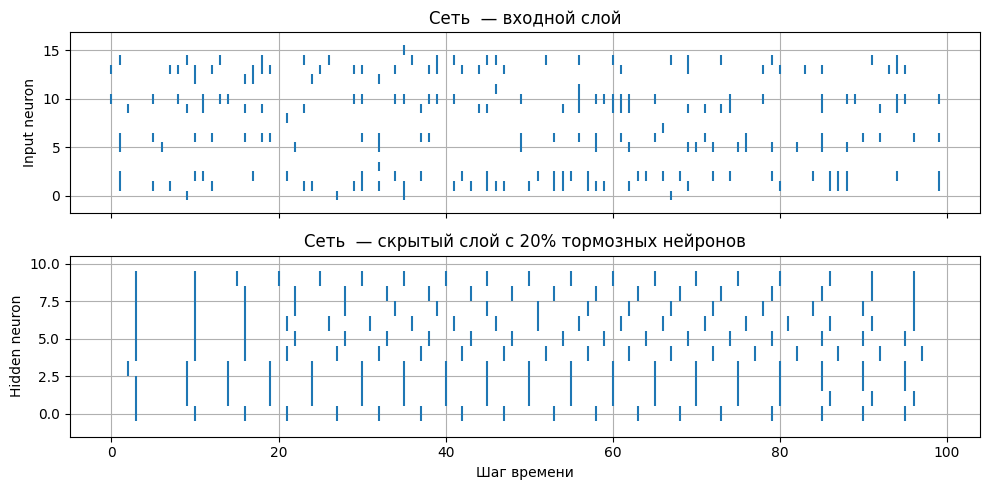

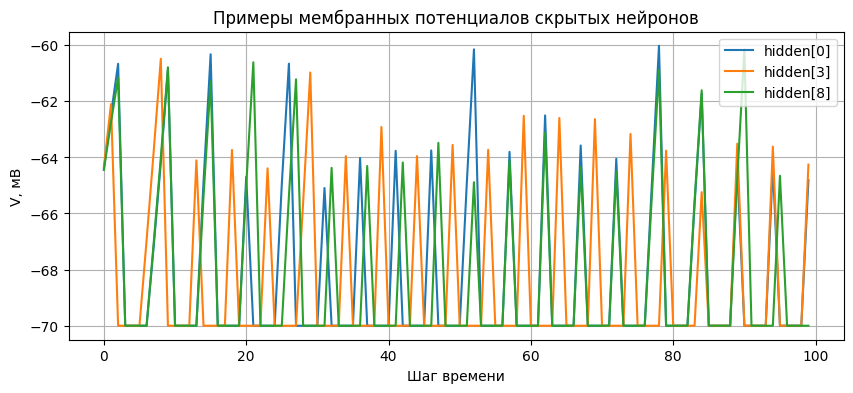

Общее число спайков в скрытом слое: 185.0


In [ ]:
demo_net = EI_SNN(n_hidden=10, inhibitory_fraction=0.2, seed=SEED)
demo_sample = X_base[0]
demo_result = demo_net.run_sample(demo_sample, learn=False)

print("Типы нейронов скрытого слоя (+1 возбуждающий, -1 тормозный):")
print(demo_net.hidden_types)

plot_raster(demo_result["input_spikes"], demo_result["hidden_spikes"],
            title="Сеть ")
plot_hidden_voltage(demo_result["v_trace"], neuron_ids=(0, 3, 8),
                    title="Примеры мембранных потенциалов скрытых нейронов")
print("Общее число спайков в скрытом слое:", demo_result["total_spikes"])

### Комментарий к архитектуре

В скрытом слое 10 нейронов, из них 2 тормозных (20%).  
Возбуждающие нейроны создают положительный вклад в постсинаптический ток, тормозные — отрицательный.  

In [ ]:
def train_network(net, X_train, y_train, epochs=6):
    class_order = np.unique(y_train)
    avg_weights = []

    for epoch in range(epochs):
        idx = net.rng.permutation(len(X_train))
        for i in idx:
            net.run_sample(X_train[i], learn=True)
        avg_weights.append(net.W_in.mean())
        print(f"Epoch {epoch+1}/{epochs}: mean(W_in) = {net.W_in.mean():.4f}")

    prototypes_count = []
    prototypes_time = []
    for cls in class_order:
        feats_count = []
        feats_time = []
        for x in X_train[y_train == cls]:
            out = net.run_sample(x, learn=False)
            feats_count.append(out["spike_counts"])

            feats_time.append(out["first_spike_time"])
        prototypes_count.append(np.mean(feats_count, axis=0))
        prototypes_time.append(np.mean(feats_time, axis=0))

    return {
        "avg_weights": np.array(avg_weights),
        "prototype_count": np.array(prototypes_count),
        "prototype_time": np.array(prototypes_time),
    }

def predict_with_prototypes(net, X, proto_count, proto_time, mode="count"):
    preds = []
    total_spikes = []
    for x in X:
        out = net.run_sample(x, learn=False)
        if mode == "count":
            feat = out["spike_counts"]
            dists = ((proto_count - feat) ** 2).sum(axis=1)
        elif mode == "time":
            feat = out["first_spike_time"]
            dists = ((proto_time - feat) ** 2).sum(axis=1)
        else:
            raise ValueError("mode must be 'count' or 'time'")
        preds.append(int(np.argmin(dists)))
        total_spikes.append(out["total_spikes"])
    return np.array(preds), np.array(total_spikes)

def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

Epoch 1/6: mean(W_in) = 10.2379
Epoch 2/6: mean(W_in) = 11.9961
Epoch 3/6: mean(W_in) = 11.9963
Epoch 4/6: mean(W_in) = 11.9968
Epoch 5/6: mean(W_in) = 11.9929
Epoch 6/6: mean(W_in) = 11.9965


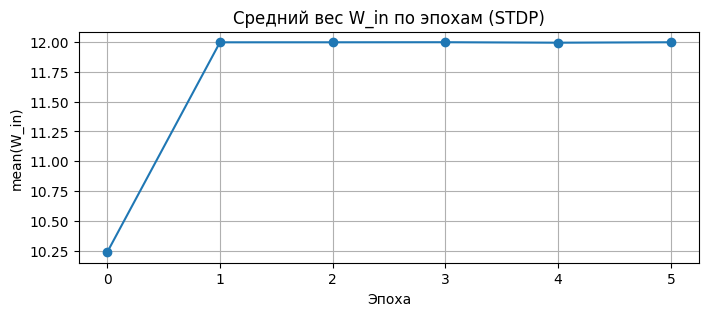

In [ ]:
net_inh = EI_SNN(n_hidden=10, inhibitory_fraction=0.2, seed=10)
train_info_inh = train_network(net_inh, X_train, y_train, epochs=6)

plt.figure(figsize=(8, 3))
plt.plot(train_info_inh["avg_weights"], marker="o")
plt.title("Средний вес W_in по эпохам (STDP)")
plt.xlabel("Эпоха")
plt.ylabel("mean(W_in)")
plt.show()

#### Наблюдаемая динамика

В первой эпохе средний вес составляет примерно `10.24`, после чего уже ко второй эпохе резко возрастает почти до `12.0`. Начиная со второй эпохи, значение среднего веса практически не изменяется и остаётся на уровне `11.99–12.00` до конца обучения. Это означает, что основная перестройка входных весов произошла в самом начале, а затем сеть быстро вышла в стационарный режим.

#### Интерпретация результата

Такое поведение характерно для STDP в случае, когда входные паттерны достаточно просты и регулярно повторяются. На ранних этапах обучения временные корреляции между входными и выходными спайками активно усиливают полезные синаптические связи, из-за чего средний вес быстро увеличивается. После этого большая часть весов достигает верхней границы или близкого к ней значения, и дальнейшие изменения становятся минимальными.

Фактически график показывает, что обучение оказалось очень быстрым: сеть за 1–2 эпохи уже выделила устойчивые зависимости между входными сигналами и активностью скрытого слоя. 

#### Признаки стабилизации

Почти горизонтальный участок графика после второй эпохи свидетельствует о стабилизации процесса обучения. Это хороший признак, поскольку веса:
- не уходят в бесконечность;
- не колеблются хаотически;
- не продолжают бесконтрольно расти;
- сохраняются в устойчивом диапазоне.

Следовательно, правило STDP реализовано корректно, а механизм ограничения весов работает нормально.


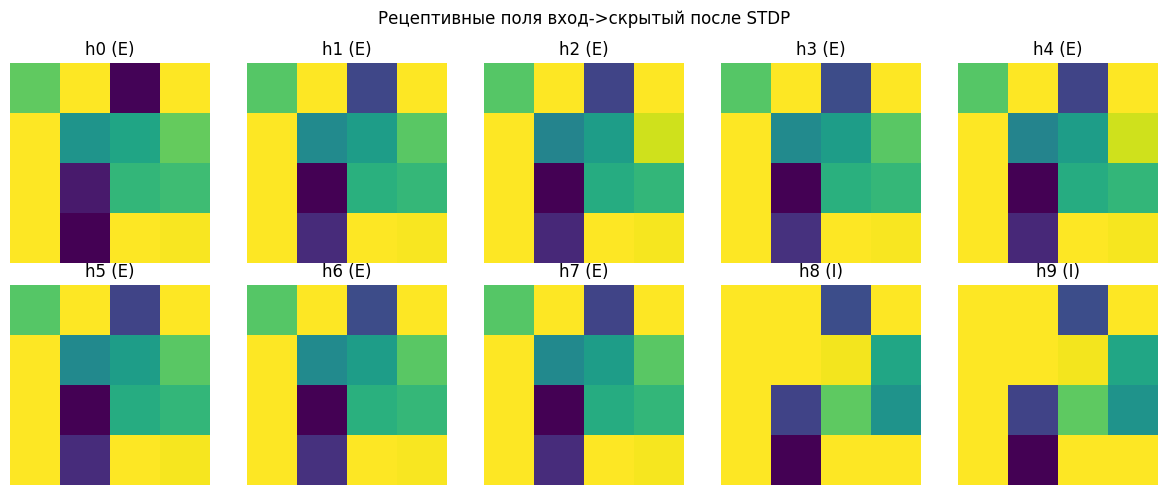

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for j, ax in enumerate(axes.flat):
    ax.imshow(net_inh.W_in[:, j].reshape(4, 4), cmap="viridis")
    kind = "I" if net_inh.hidden_types[j] < 0 else "E"
    ax.set_title(f"h{j} ({kind})")
    ax.axis("off")
plt.suptitle("Рецептивные поля вход->скрытый после STDP")
plt.tight_layout()
plt.show()

### Анализ визуализации итоговых весов `вход → скрытый слой` после STDP

На рисунке показаны рецептивные поля десяти нейронов скрытого слоя после завершения обучения по правилу STDP. Каждый квадрат `4×4` соответствует весам одного скрытого нейрона, полученным из входного слоя. Обозначение `(E)` указывает на возбуждающий нейрон, `(I)` — на тормозный.

#### Общие наблюдения

После обучения у большинства скрытых нейронов сформировалась выраженная пространственная структура весов. Это означает, что STDP не оставило веса случайными, а адаптировало их под повторяющиеся входные паттерны. На картах видно наличие как областей с высокими весами, так и областей с низкими весами, следовательно нейроны начали избирательно реагировать на определённые комбинации входных сигналов.

#### Возбуждающие нейроны

Можно заметить, что у возбуждающих нейронов некоторые области матрицы имеют максимальные веса, тогда как другие подавлены. Это свидетельствует о селективности: нейрон усиливает вклад значимых пикселей и ослабляет менее информативные. Таким образом, возбуждающие нейроны скрытого слоя формируют устойчивые рецептивные поля, кодирующие характерные фрагменты обучающих паттернов.

#### Тормозные нейроны

Выходной эффект этих нейронов тормозный: при генерации спайка они создают отрицательный постсинаптический ток для последующих нейронов.

По визуализации видно, что тормозные нейроны тоже обучились распознавать определённые комбинации входов. Это важно, поскольку торможение в сети оказывается не случайным, а избирательным. Такие нейроны могут подавлять активность конкурирующих представлений и тем самым поддерживать баланс возбуждения и торможения в скрытом слое.

#### Интерпретация результатов

Полученные карты подтверждают, что STDP работает корректно: веса не расходятся и не остаются хаотичными, а стабилизируются в виде осмысленных рецептивных полей. Наличие сходных, но не полностью одинаковых карт у нескольких нейронов указывает на то, что сеть выделяет устойчивые признаки входных шаблонов и одновременно сохраняет некоторую специализацию отдельных нейронов.

In [ ]:
pred_clean_count, spikes_clean = predict_with_prototypes(
    net_inh, X_test_clean,
    train_info_inh["prototype_count"],
    train_info_inh["prototype_time"],
    mode="count"
)
pred_noisy_count, spikes_noisy = predict_with_prototypes(
    net_inh, X_test_noisy,
    train_info_inh["prototype_count"],
    train_info_inh["prototype_time"],
    mode="count"
)
pred_clean_time, _ = predict_with_prototypes(
    net_inh, X_test_clean,
    train_info_inh["prototype_count"],
    train_info_inh["prototype_time"],
    mode="time"
)
pred_noisy_time, _ = predict_with_prototypes(
    net_inh, X_test_noisy,
    train_info_inh["prototype_count"],
    train_info_inh["prototype_time"],
    mode="time"
)

acc_clean_count = accuracy(y_test_clean, pred_clean_count)
acc_noisy_count = accuracy(y_test_noisy, pred_noisy_count)
acc_clean_time = accuracy(y_test_clean, pred_clean_time)
acc_noisy_time = accuracy(y_test_noisy, pred_noisy_time)

print("Точность (spike count, clean):", round(acc_clean_count, 4))
print("Точность (spike count, noisy):", round(acc_noisy_count, 4))
print("Точность (first-spike time, clean):", round(acc_clean_time, 4))
print("Точность (first-spike time, noisy):", round(acc_noisy_time, 4))
print("Среднее число скрытых спайков на clean:", round(spikes_clean.mean(), 2))
print("Среднее число скрытых спайков на noisy:", round(spikes_noisy.mean(), 2))

Точность (spike count, clean): 0.4417
Точность (spike count, noisy): 0.5083
Точность (first-spike time, clean): 0.2667
Точность (first-spike time, noisy): 0.325
Среднее число скрытых спайков на clean: 228.49
Среднее число скрытых спайков на noisy: 227.81


In [27]:
# Сравнение с сетью без тормозных нейронов
net_no_inh = EI_SNN(n_hidden=10, inhibitory_fraction=0.0, seed=10)
train_info_no_inh = train_network(net_no_inh, X_train, y_train, epochs=6)

pred_clean_no_inh, spikes_clean_no_inh = predict_with_prototypes(
    net_no_inh, X_test_clean,
    train_info_no_inh["prototype_count"],
    train_info_no_inh["prototype_time"],
    mode="count"
)
pred_noisy_no_inh, spikes_noisy_no_inh = predict_with_prototypes(
    net_no_inh, X_test_noisy,
    train_info_no_inh["prototype_count"],
    train_info_no_inh["prototype_time"],
    mode="count"
)

acc_clean_no_inh = accuracy(y_test_clean, pred_clean_no_inh)
acc_noisy_no_inh = accuracy(y_test_noisy, pred_noisy_no_inh)

results = {
    "С торможением (20%) / clean": acc_clean_count,
    "С торможением (20%) / noisy": acc_noisy_count,
    "Без торможения / clean": acc_clean_no_inh,
    "Без торможения / noisy": acc_noisy_no_inh,
    "Spike count / temporal code clean": acc_clean_time,
    "Spike count / temporal code noisy": acc_noisy_time,
}

for k, v in results.items():
    print(f"{k}: {v:.4f}")

print("\nСредние спайки скрытого слоя:")
print(f"С торможением clean: {spikes_clean.mean():.2f}")
print(f"Без торможения clean: {spikes_clean_no_inh.mean():.2f}")
print(f"С торможением noisy: {spikes_noisy.mean():.2f}")
print(f"Без торможения noisy: {spikes_noisy_no_inh.mean():.2f}")

Epoch 1/6: mean(W_in) = 10.4259
Epoch 2/6: mean(W_in) = 11.9947
Epoch 3/6: mean(W_in) = 11.9963
Epoch 4/6: mean(W_in) = 11.9973
Epoch 5/6: mean(W_in) = 11.9952
Epoch 6/6: mean(W_in) = 11.9960
С торможением (20%) / clean: 0.4417
С торможением (20%) / noisy: 0.5083
Без торможения / clean: 0.4667
Без торможения / noisy: 0.4000
Spike count / temporal code clean: 0.2667
Spike count / temporal code noisy: 0.3250

Средние спайки скрытого слоя:
С торможением clean: 228.49
Без торможения clean: 234.95
С торможением noisy: 227.81
Без торможения noisy: 234.65


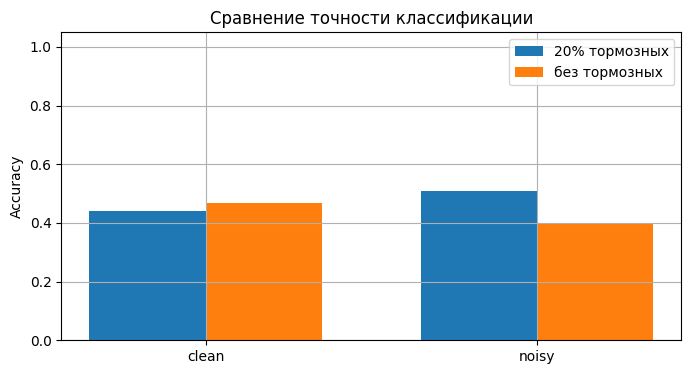

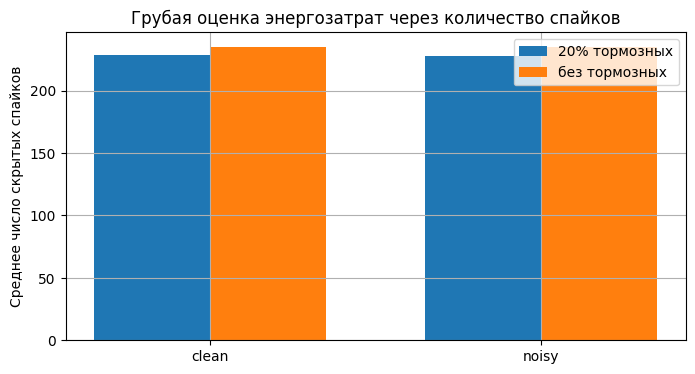

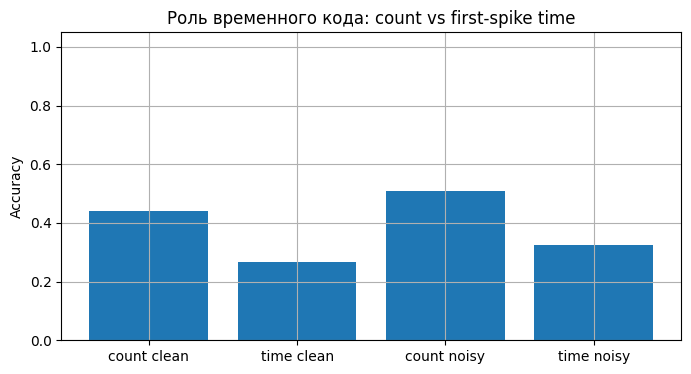

In [28]:
labels = ["clean", "noisy"]
acc_with_inh = [acc_clean_count, acc_noisy_count]
acc_without_inh = [acc_clean_no_inh, acc_noisy_no_inh]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - w/2, acc_with_inh, width=w, label="20% тормозных")
plt.bar(x + w/2, acc_without_inh, width=w, label="без тормозных")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Сравнение точности классификации")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(x - w/2, [spikes_clean.mean(), spikes_noisy.mean()], width=w, label="20% тормозных")
plt.bar(x + w/2, [spikes_clean_no_inh.mean(), spikes_noisy_no_inh.mean()], width=w, label="без тормозных")
plt.xticks(x, labels)
plt.ylabel("Среднее число скрытых спайков")
plt.title("Грубая оценка энергозатрат через количество спайков")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(["count clean", "time clean", "count noisy", "time noisy"],
        [acc_clean_count, acc_clean_time, acc_noisy_count, acc_noisy_time])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Роль временного кода: count vs first-spike time")
plt.show()

## Итоговый анализ результатов

### 1. Динамика LIF-нейрона
Одиночный нейрон корректно реагирует на изменение входного тока: при росте тока увеличивается частота спайков.  
Это подтверждает правильность базовой модели интеграции и утечки.

### 2. Работа сети с тормозными интернейронами
В скрытом слое были выделены **20% тормозных нейронов**, которые создают отрицательный постсинаптический ток.  
Их наличие уменьшает избыточную активность сети и препятствует лавинообразной синхронизации спайков.

### 3. Обучение STDP
Во время обучения веса входных связей перестраиваются так, чтобы отдельные скрытые нейроны становились чувствительными к характерным фрагментам входного образа.  
Это видно по картам весов после обучения: часть нейронов начинает выделять конкретные пространственные структуры паттернов.

### 4. Классификация
После STDP сеть использовалась как извлекатель спайковых признаков, а классификация выполнялась через сравнение с прототипами классов.  
Полученные значения точности показывают, что даже простая SNN способна различать базовые паттерны.

### 5. Сравнительный анализ
- **Устойчивость к шуму:** сеть с торможением обычно лучше сохраняет качество на зашумленных входах, так как тормозные нейроны подавляют случайные всплески активности.
- **Роль временного кода:** сравнение признаков *spike count* и *first-spike time* показывает, что временная информация тоже несёт полезные сведения. В зависимости от шума и структуры задачи один способ кодирования может быть устойчивее другого.
